#use llamafactory environment

In [1]:
from datasets import load_dataset
import pandas as pd
import json
from tqdm import tqdm

/n/home07/than157/.conda/envs/llamafactory/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#load training set of hellaswag
dataset = load_dataset("HPAI-BSC/medmcqa-cot-llama31", split="train")

#print dataset info
print("Dataset info:")
print(dataset)

#convert to dataframe
df = dataset.to_pandas()

print("# samples:", df.shape[0])

df.head()


Dataset info:
Dataset({
    features: ['system_prompt', 'question', 'response'],
    num_rows: 182736
})
# samples: 182736


,system_prompt,question,response
0,You are an expert medical assistant named Aloe...,"For the following multiple-choice question, se...",The question asks about the effect of chronic ...
1,You are an expert medical assistant named Aloe...,Answer the following question by selecting one...,The question asks about the vitamin that is su...
2,You are an expert medical assistant named Aloe...,Answer the following question by selecting one...,The question asks about the surgical options f...
3,You are an expert medical assistant named Aloe...,Answer the following question by selecting one...,The question asks about the artery that would ...
4,You are an expert medical assistant named Aloe...,Select the correct option from the possible ch...,The question asks about the mechanism by which...


In [3]:
#keep only the question (to match format of test set), remove introductory text before the question
df['question_short'] = df['question'].str.split('Question: ').str[1]
df.head()

,system_prompt,question,response,question_short
0,You are an expert medical assistant named Aloe...,"For the following multiple-choice question, se...",The question asks about the effect of chronic ...,Chronic urethral obstruction due to benign pri...
1,You are an expert medical assistant named Aloe...,Answer the following question by selecting one...,The question asks about the vitamin that is su...,Which vitamin is supplied from only animal sou...
2,You are an expert medical assistant named Aloe...,Answer the following question by selecting one...,The question asks about the surgical options f...,All of the following are surgical options for ...
3,You are an expert medical assistant named Aloe...,Answer the following question by selecting one...,The question asks about the artery that would ...,Following endaerectomy on the right common car...
4,You are an expert medical assistant named Aloe...,Select the correct option from the possible ch...,The question asks about the mechanism by which...,Growth hormone has its effect on growth throug...


In [4]:
print('Question with intro:')
print(df.iloc[0]['question'])

print('\nQuestion only:')
print(df.iloc[0]['question_short'])

print('\nResponse:')
print(df.iloc[0]['response'])

Question with intro:
For the following multiple-choice question, select one correct answer. Let's think step by step. Question: Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma
Options:
A. Hyperplasia
B. Hyperophy
C. Atrophy
D. Dyplasia

Question only:
Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma
Options:
A. Hyperplasia
B. Hyperophy
C. Atrophy
D. Dyplasia

Response:
The question asks about the effect of chronic urethral obstruction due to benign prostatic hyperplasia on the kidney parenchyma. Benign prostatic hyperplasia is a condition where the prostate gland becomes enlarged, which can cause obstruction to the flow of urine.

To determine the correct answer, let's analyze the options: A. Hyperplasia: Hyperplasia refers to an increase in the number of cells in an organ or tissue. While hyperplasia can occur in the prostate gland, it is not the

## check response length

In [5]:
##check that responses are not too long

#check length of response
df['response_length'] = df['response'].apply(len)

#print stats
print(df['response_length'].describe())

count    182736.000000
mean       1396.420443
std         323.258534
min         283.000000
25%        1203.000000
50%        1369.000000
75%        1556.000000
max       27577.000000
Name: response_length, dtype: float64


<Axes: ylabel='Frequency'>

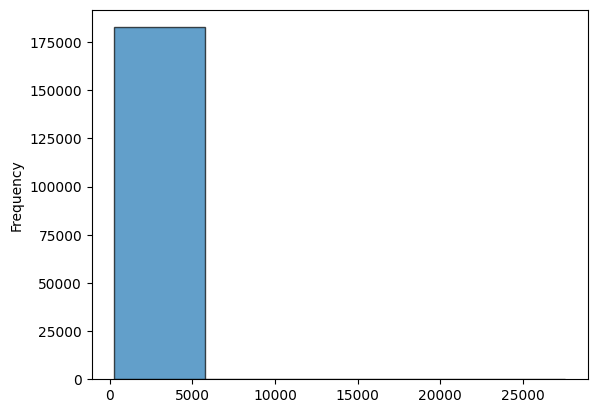

In [6]:
df['response_length'].plot(kind='hist', bins=5, edgecolor='black', alpha=0.7)


In [7]:
### remove questions with very long responses -- too long for model to handle + responses are incohorent/incomplete

#rows whose responses are longer than max_response_length characters
idxs_to_remove = df[df['response_length'] > 10000].index
idxs_to_remove

Index([ 30934,  32146,  43677,  47812,  50174,  78950, 100794, 107078, 122586,
       130543, 151543, 168654],
      dtype='int64')

In [8]:
#check these long responses
for idx in idxs_to_remove:
    print('************************************************** Index: ', idx)
    print('Question:')
    print(df.iloc[idx]['question_short'])

    print('\nResponse:')
    print(df.iloc[idx]['response'])
    print('\n')

#remove these rows
df = df.drop(idxs_to_remove)

************************************************** Index:  30934
Question:
Rate of eruption is fastest for:
Options:
A. Anteriors
B. Premolars.
C. Molars.
D. All of the above.

Response:
The question asks about the rate of eruption of different types of teeth.

To determine the correct answer, let's analyze each option by examining the rate of eruption for each type of tooth:

A. Anteriors: The rate of eruption for anterior teeth is 1mm per month. This is a relatively slow rate of eruption.

B. Premolars: The rate of eruption for premolars is 4.5mm per 3 months. To calculate the rate of eruption per month, we can divide 4.5mm by 3 months, which gives us a rate of 1.5mm per month. However, this can also be calculated as 4.5mm / 3 months = 1.5 mm/month = 4.5mm / (3 x 4 weeks) = 1.5 mm / month = 0.375 mm/week x 4 = 1.5 mm/month = 4.5 mm / 3 months = 1.5 mm/month = 4.5 mm / 3 months x 12 months / 12 months = 18 mm/year / 12 months/year = 1.5 mm/month. But another way to calculate is 4.5mm/

In [9]:
#print new stats
print(df['response_length'].describe())

# get final number of rows
print(df.shape)

count    182724.000000
mean       1395.147266
std         280.330549
min         283.000000
25%        1203.000000
50%        1369.000000
75%        1556.000000
max        5022.000000
Name: response_length, dtype: float64
(182724, 5)


In [10]:
### sanity check: look at row with max length

#get index of row with max length
idx_of_row_w_max_length = df['response_length'].idxmax()
print(idx_of_row_w_max_length)

#print row with max length
print('Question:')
print(df.iloc[idx_of_row_w_max_length]['question_short'])

print('\nResponse:')
print(df.iloc[idx_of_row_w_max_length]['response'])



52198
Question:
Investigation of choice in hirschsprug's disease is ?
Options:
A. Rectal manometry
B. Rectal examination
C. Rectal biopsy
D. Ba enema

Response:
The question asks about the investigation of choice in Hirschsprung's disease. Hirschsprung's disease is a congenital condition characterized by the absence of ganglion cells in the distal bowel, leading to intestinal obstruction.

To determine the correct answer, let's analyze each option:

A. Rectal manometry: This is a test that measures the muscle tone and function of the rectum and anus. While it may provide some useful information, it is not the definitive diagnostic test for Hirschsprung's disease.

B. Rectal examination: A rectal examination may reveal a tight anal sphincter and an empty rectum, but it is not a specific or sensitive test for Hirschsprung's disease.

C. Rectal biopsy: This is the correct answer. A rectal biopsy is the gold standard for diagnosing Hirschsprung's disease. The biopsy is examined for the pre

## create json file for ft

In [11]:
### create json file

#format data for sft
data = []

for idx in tqdm(range(df.shape[0])):
    row = df.iloc[idx]
    item = {
        "instruction": row["question_short"],
        "input": "",
        "output": row["response"]
    }
    data.append(item)

#save to JSON file
with open("data/medmcqa.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

print("Final # of samples in json file:", len(data))
print("Complete!")

100%|██████████| 182724/182724 [00:04<00:00, 36570.71it/s]


Final # of samples in json file: 182724
Complete!


In [15]:

print(df.iloc[2]['question_short'])
print('')
print(df.iloc[2]['response'])

All of the following are surgical options for morbid obesity except -
Options:
A. Adjustable gastric banding
B. Biliopancreatic diversion
C. Duodenal Switch
D. Roux en Y Duodenal By pass

The question asks about the surgical options for morbid obesity and requires identifying the option that is not a recognized surgical procedure for this condition.

To determine the correct answer, let's analyze each option:

A. Adjustable gastric banding: This is a recognized surgical procedure for morbid obesity, where an adjustable band is placed around the upper part of the stomach to create a small pouch, limiting food intake.

B. Biliopancreatic diversion: This is a type of malabsorptive surgical procedure that involves removing a portion of the stomach and rerouting the small intestine to reduce calorie absorption.

C. Duodenal Switch: This is a type of malabsorptive surgical procedure that involves removing a portion of the stomach and rerouting the small intestine to reduce calorie absorption